# Seasonal Agriculture Performance Analysis

**Major Data Analytics Project**

* **Domain:** Agriculture
* **Project Theme:** Seasonal Agriculture Performance
* **Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Project Goal**
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

*Important: This is a Data Analytics project. No Machine Learning or dashboard development is required.*

# 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.

# 2. Project Objectives

* Understand the structure and quality of the agricultural dataset.
* Clean and prepare the data for analysis.
* Explore seasonal patterns in the dataset.
* Perform descriptive and statistical analysis.
* Investigate relationships among relevant variables.
* Compare agricultural performance across seasons and other meaningful groups.
* Identify significant findings from the data.
* Develop evidence-based insights and recommendations.


## 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

Dataset file: `seasonal_agriculture_performance_dataset.csv`

The notebook is designed so that students can upload/place the CSV in the same folder as this notebook.

#PART:1 — Imports
I started by importing the libraries I need for this project. Pandas is for loading and working with the data, NumPy helps with numeric operations, and Matplotlib and Seaborn are for creating charts and graphs. I also set a clean visual style so all my plots look consistent throughout the notebook. This is just a setup step before any real analysis begins.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries imported successfully.")

Libraries imported successfully.


#PART:2 — Load Dataset
#TASK-1
Here I loaded the CSV file containing the seasonal agriculture data into a pandas DataFrame called df. I printed the number of records just to confirm that the file was read correctly and nothing went wrong during loading. This is the very first step of any data analysis project — getting the raw data into a usable format.


In [2]:
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")
print("Dataset loaded successfully.")
print("Number of records:", len(df))

Dataset loaded successfully.
Number of records: 4000


#PART:3 — Top 5 Rows
#TASK-2
I used df.head() to look at the first five rows of the dataset. This gives me a quick preview of what the actual data looks like — the column values, the format they're in, and whether everything loaded properly. It's a simple sanity check before diving deeper.


   Farm_ID           State  District    Crop  Season  Farm_Area_Hectares  \
0  SF10001  Andhra Pradesh    Rajkot   Wheat  Kharif                0.53   
1  SF10002     Maharashtra  Nalgonda   Maize  Kharif                6.53   
2  SF10003       Telangana  Warangal  Pulses    Rabi                4.86   
3  SF10004       Telangana    Indore    Rice  Kharif                4.50   
4  SF10005       Karnataka  Ludhiana   Maize    Zaid                4.21   

   Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  ...  \
0        486.4               24.3          69.1                 5.8  ...   
1        855.4               25.7          78.4                 5.1  ...   
2        455.6               23.9          56.4                10.3  ...   
3        753.2               29.7          65.2                 6.3  ...   
4        101.6               34.1          55.2                 6.5  ...   

   Seed_Quality_Score  Yield_Tonnes_Ha  Production_Tonnes  \
0                0.76    

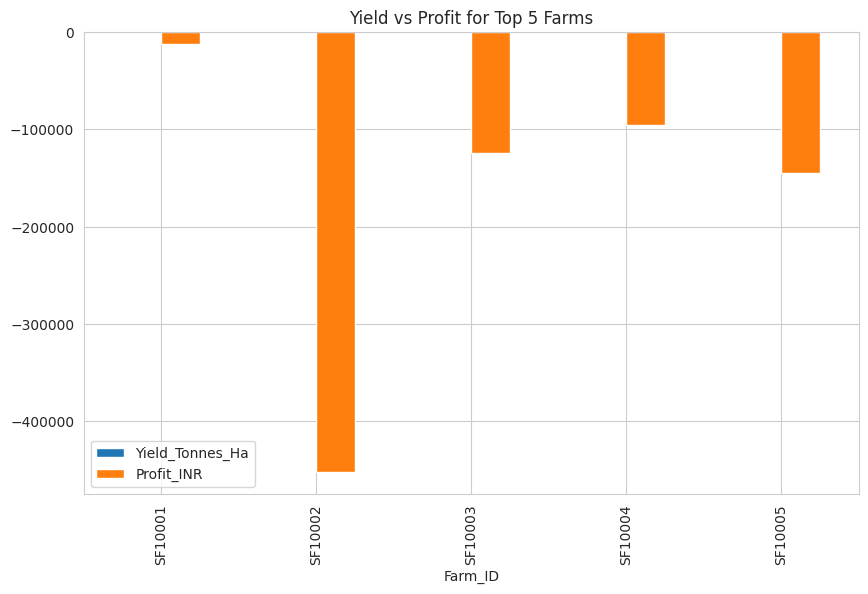

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [3]:
top_5 = df.head(5)
df.head()
print(top_5)
print(top_5.describe())
top_5.plot(x="Farm_ID", y=["Yield_Tonnes_Ha", "Profit_INR"], kind="bar")
plt.title("Yield vs Profit for Top 5 Farms")
plt.show()
df.tail(5)


#PART:4 — Shape and Structure
#TASK-3
This cell tells me how many rows and columns are in the dataset, and lists out all the column names. Knowing the shape (4000 rows, 28 columns) helps me understand the scale of the data I'm working with. Seeing the column names also helps me plan which fields are useful for the seasonal comparison I need to do.


In [4]:
print("Shape of dataset:", df.shape)

df.describe()
print("Column names:")
print(list(df.columns))

Shape of dataset: (4000, 28)
Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


#PART:5 — Data Types
# TASK-4
Here I checked what type of data each column holds — text (categorical) or numbers (numerical). This matters because I need to treat them differently: numerical columns can be averaged or correlated, while categorical columns like Season or Crop are better suited for grouping and counting. Separating them early made the rest of my analysis easier to plan.


In [5]:
print(df.dtypes)
df.info()
print("\nCategorical columns:", list(df.select_dtypes(include=['object']).columns))
print("Numerical columns:", list(df.select_dtypes(include=['number']).columns))


Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

#PART:6 — Identify Missing Values
#TASK-5
Before doing any analysis, I checked whether any columns had missing (empty) values, since missing data can quietly mess up calculations later. I found that three columns — Rainfall, Soil Moisture, and Yield — had a small number of missing values, less than 1.5% each. This step is important because you should never analyze data without first knowing its quality.


In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print("Percentage missing:")
print((missing / len(df) * 100).round(2))

Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64
Percentage missing:
Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64


#PART:7 — Handle Missing Values
Instead of just deleting rows with missing values or filling them with one overall average, I filled each missing value using the median of that same season. I did this because rainfall, soil moisture, and yield naturally differ from season to season, so using a season-specific median keeps that seasonal pattern intact instead of flattening it out. After this step, the dataset had zero missing values left.


In [7]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Total missing values after treatment:", df.isnull().sum().sum())

Total missing values after treatment: 0


In [8]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


#PART:8 — Duplicate Records
#TASK-6
I checked whether the dataset had any exact duplicate rows or repeated Farm IDs, since duplicate records can distort averages and totals. In this dataset, there were no duplicates at all, so no rows needed to be removed. I still included the duplicate-check code because it's good practice to verify this rather than assume it.


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())
print("Number of duplicate Farm_IDs:", df['Farm_ID'].duplicated().sum())

df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 0
Number of duplicate Farm_IDs: 0
Shape after dropping duplicates: (4000, 28)


Checking the values of Numerical and categorical columns

In [10]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
print("\nCategorical columns:")
print(categorical_columns)
print("Numerical columns:")
print(numeric_columns)


Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']
Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


#PART:9 — Descriptive Statistics
#TASK-7
This cell gives the standard statistical summary of every numeric column — mean, minimum, maximum, and percentile values. Looking at this table, I immediately noticed that some columns like Yield and Profit have a mean that's much higher than their median, which usually signals that a few extreme values are pulling the average up. This gave me a hint that I needed to look into outliers next.


In [11]:
pd.set_option('display.max_columns', None)
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.714313,288.427366,80.000,370.425,581.0000,836.12500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.504525,6.696998,8.000,21.700,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [12]:
#This line says the mean and median columns from describe() and flags which columns have a higher mean and median

# Create the summary dataframe incorporating describe statistics, Std_Dev, Min, Max, and the Difference
summary = df[numeric_columns].describe().T[['mean', '50%', 'std', 'min', 'max']]
summary.rename(columns={'50%': 'median', 'std': 'Std_Dev', 'min': 'Min', 'max': 'Max', 'mean': 'Mean'}, inplace=True)
summary['Difference'] = summary['Mean'] - summary['median']

# Display the final summary table
print(summary[['Mean', 'median', 'Std_Dev', 'Min', 'Max', 'Difference']])

                                        Mean       median        Std_Dev  \
Farm_Area_Hectares                  7.888265       7.8950       4.223764   
Rainfall_mm                       600.714313     581.0000     288.427366   
Avg_Temperature_C                  26.818900      26.9000       3.818180   
Humidity_pct                       63.210500      63.0000      11.960834   
Sunlight_Hours_Day                  7.323050       7.3000       1.121186   
Soil_pH                             6.701010       6.6900       0.641461   
Soil_Moisture_pct                  26.504525      26.4000       6.696998   
Nitrogen_kg_ha                    120.250825     120.1000      31.216452   
Phosphorus_kg_ha                   57.781850      57.5000      17.015074   
Potassium_kg_ha                   104.760050     105.1000      27.742681   
Fertilizer_kg_ha                  186.036000     186.2500      60.260583   
Pesticide_Litre_ha                  5.070935       5.1200       1.978879   
Seed_Quality

#PART:10 — Outlier Investigation
#TASK-8
I used the IQR (Interquartile Range) method to statistically detect outliers — values that are unusually high or low compared to the rest of the data. Columns like Yield, Production, and Profit had around 7–10% outliers, which I confirmed visually using boxplots. I chose to keep these outliers rather than delete them, since they likely represent real farms that performed exceptionally well or badly, and removing them would hide genuine seasonal risk.


Yield_Tonnes_Ha: 302 outliers detected (7.55%)
Profit_INR: 404 outliers detected (10.10%)


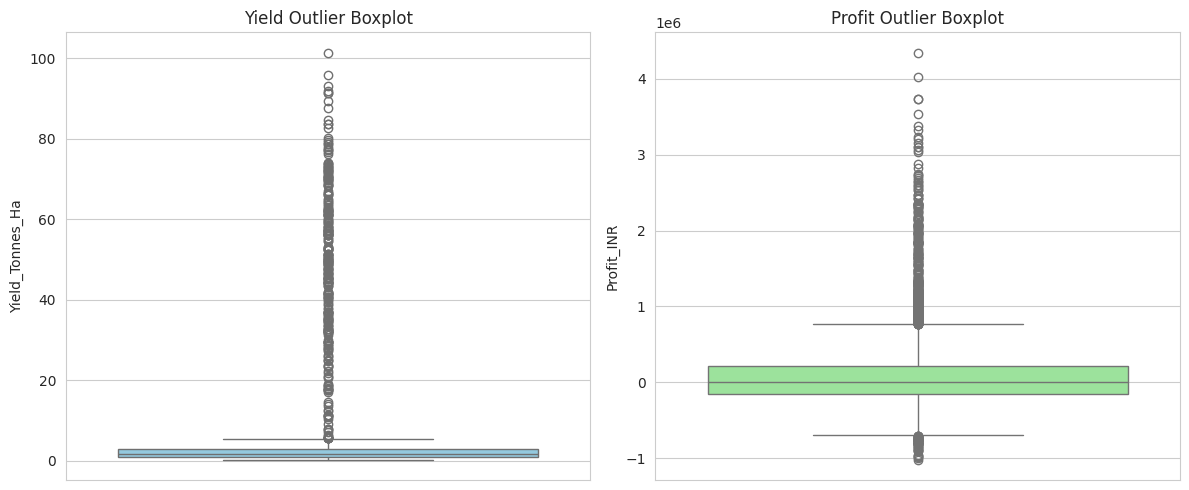


Top 5 Extreme Profit Farms (Legitimate high-performing observations):
      Farm_ID       Crop  Farm_Area_Hectares  Total_Cost_INR  Revenue_INR  \
2236  SF12237     Chilli               12.74          712027      5057448   
626   SF10627     Chilli               14.45         1059050      5080900   
3425  SF13426  Sugarcane               13.96          745161      4485260   
1690  SF11691     Chilli               13.04          784135      4522464   
247   SF10248     Chilli               14.86         1283161      4825365   

      Profit_INR  
2236     4345421  
626      4021850  
3425     3740099  
1690     3738329  
247      3542204  


In [13]:
# 1. Statistical Detection using IQR Bounds for Profit and Yield
for col in ['Yield_Tonnes_Ha', 'Profit_INR']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    pct = (len(outliers) / len(df)) * 100
    print(f"{col}: {len(outliers)} outliers detected ({pct:.2f}%)")

# 2. Visual confirmation using Boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['Yield_Tonnes_Ha'], ax=axes[0], color='skyblue')
axes[0].set_title('Yield Outlier Boxplot')

sns.boxplot(y=df['Profit_INR'], ax=axes[1], color='lightgreen')
axes[1].set_title('Profit Outlier Boxplot')
plt.tight_layout()
plt.show()

# 3. Investigation: Inspecting extreme legitimate observations
extreme_cases = df.nlargest(5, 'Profit_INR')[['Farm_ID', 'Crop', 'Farm_Area_Hectares', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR']]
print("\nTop 5 Extreme Profit Farms (Legitimate high-performing observations):")
print(extreme_cases)

#PART:11 — Univariate Analysis
#TASK-9
This cell looks at individual columns one at a time to understand their basic distribution. I plotted how yield values are spread out, how many records exist per season, per crop, and per irrigation method. This helped me notice, for example, that Kharif and Rabi seasons have far more records than Zaid, which is something I had to keep in mind while comparing seasons later.


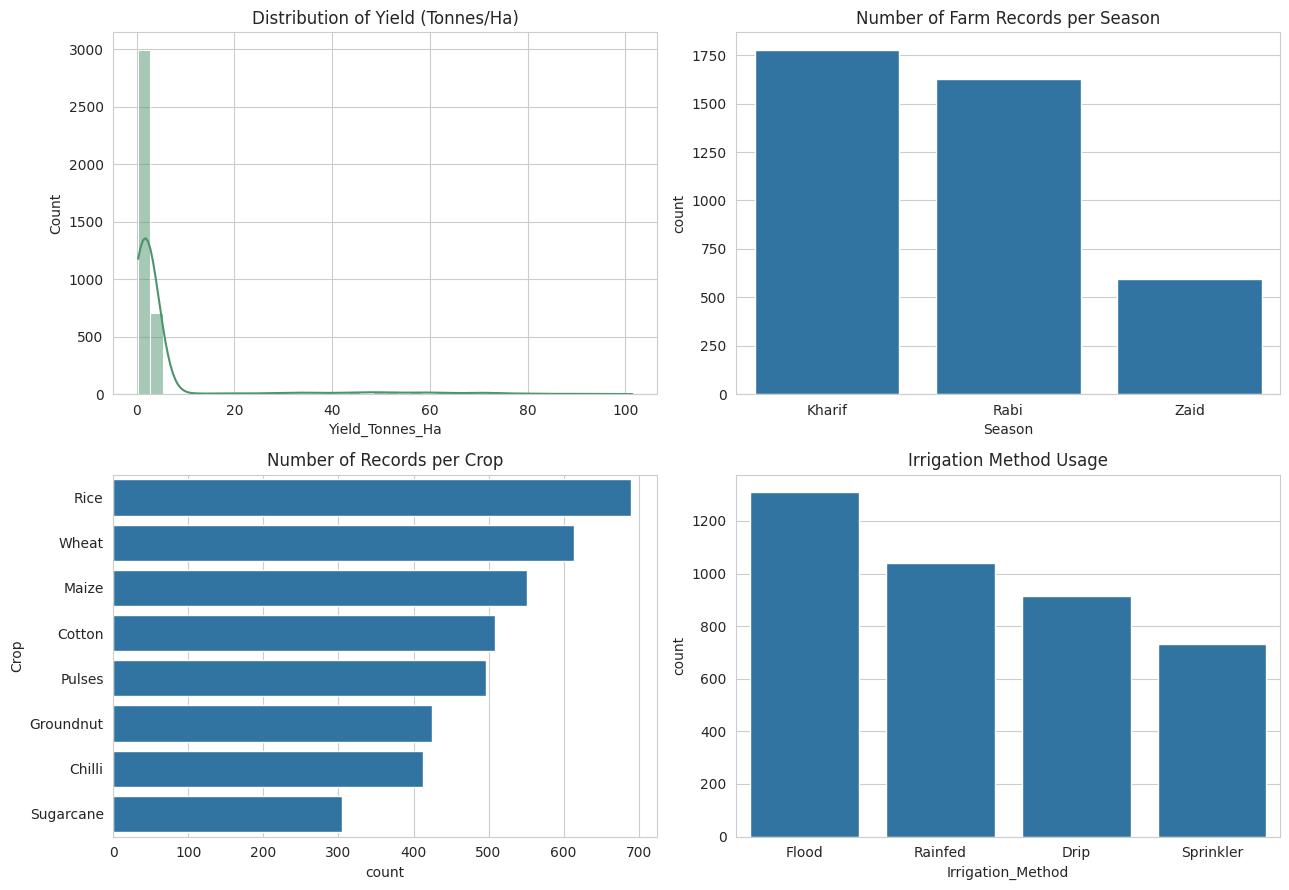

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df['Yield_Tonnes_Ha'], bins=40, kde=True, ax=axes[0,0], color="#4C956C")
axes[0,0].set_title("Distribution of Yield (Tonnes/Ha)")

sns.countplot(x='Season', data=df, order=df['Season'].value_counts().index, ax=axes[0,1])
axes[0,1].set_title("Number of Farm Records per Season")

sns.countplot(y='Crop', data=df, order=df['Crop'].value_counts().index, ax=axes[1,0])
axes[1,0].set_title("Number of Records per Crop")

sns.countplot(x='Irrigation_Method', data=df, order=df['Irrigation_Method'].value_counts().index, ax=axes[1,1])
axes[1,1].set_title("Irrigation Method Usage")

plt.tight_layout()
plt.show()

print(df['Season'].value_counts())
print(df['Irrigation_Method'].value_counts())

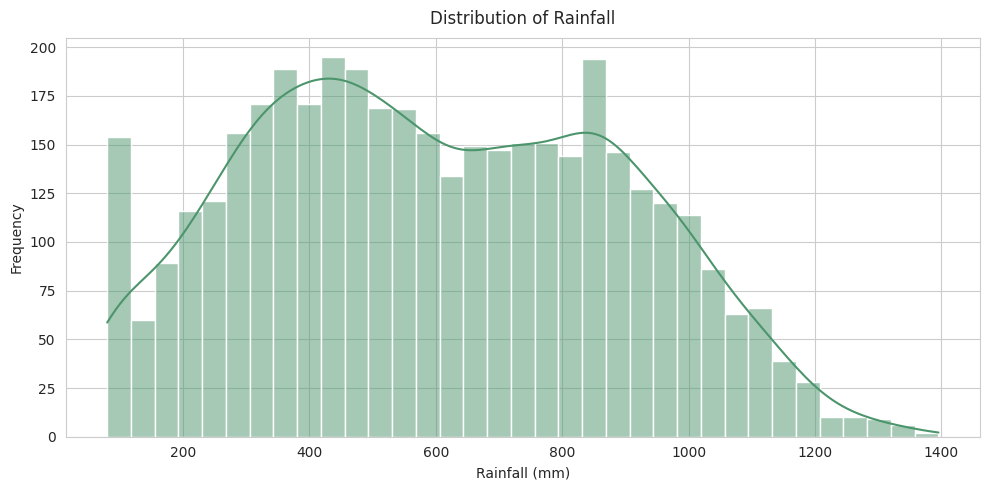

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True, color="#4C956C", bins=35)
plt.title("Distribution of Rainfall", fontsize=12, pad=10)
plt.xlabel("Rainfall (mm)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.tight_layout()
plt.show()

#PART:12 — Bivariate Analysis
#TASK-10
Here I started comparing two variables at a time to look for relationships. I compared yield and profit across the three seasons using boxplots, and checked whether rainfall or fertilizer amount visually relates to yield using scatter plots. This is where I first noticed that Kharif has better yield and profit than the other two seasons.


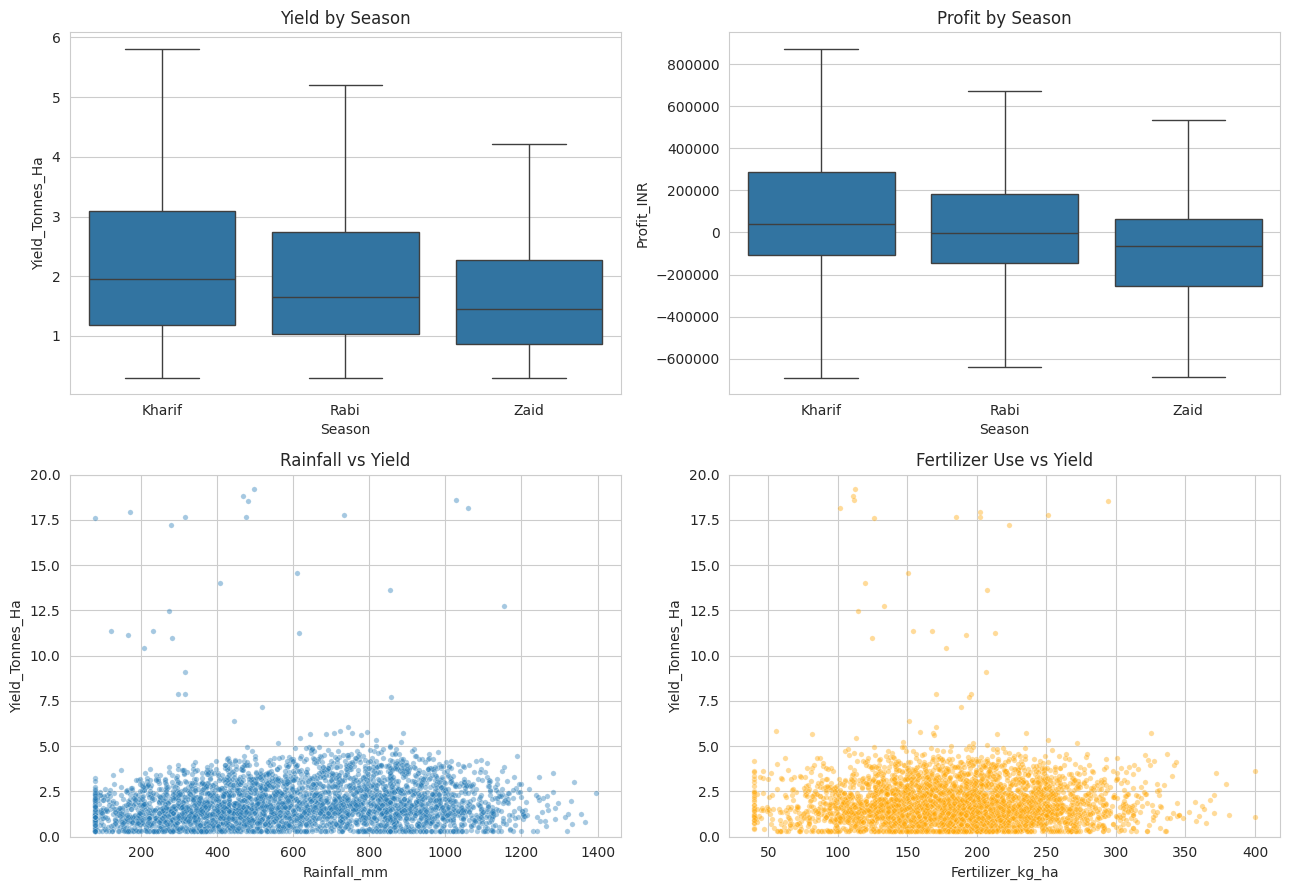

Season
Kharif    1.95
Rabi      1.66
Zaid      1.45
Name: Yield_Tonnes_Ha, dtype: float64
Season
Kharif    38808.0
Rabi      -3187.0
Zaid     -62144.0
Name: Profit_INR, dtype: float64


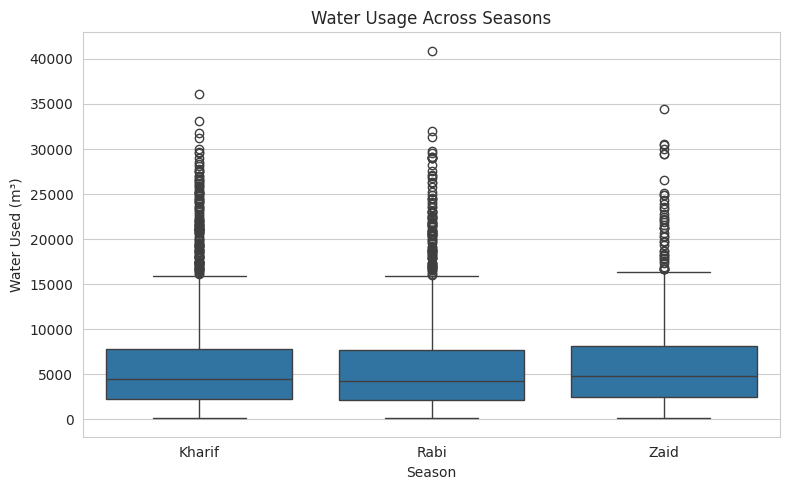

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.boxplot(
    x="Season",
    y="Yield_Tonnes_Ha",
    data=df,
    ax=axes[0, 0],
    showfliers=False,
)
axes[0, 0].set_title("Yield by Season")

sns.boxplot(x="Season", y="Profit_INR", data=df, ax=axes[0, 1], showfliers=False)
axes[0, 1].set_title("Profit by Season")

sns.scatterplot(
    x="Rainfall_mm", y="Yield_Tonnes_Ha", data=df, ax=axes[1, 0], alpha=0.4, s=15
)
axes[1, 0].set_title("Rainfall vs Yield")
axes[1, 0].set_ylim(0, 20)

sns.scatterplot(
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha",
    data=df,
    ax=axes[1, 1],
    alpha=0.4,
    s=15,
    color="orange",
)
axes[1, 1].set_title("Fertilizer Use vs Yield")
axes[1, 1].set_ylim(0, 20)

plt.tight_layout()
plt.show()

print(df.groupby("Season")["Yield_Tonnes_Ha"].median())
print(df.groupby("Season")["Profit_INR"].median())


plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Water_Used_m3")
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.tight_layout()
plt.show()

#PART:13 — Multivariate Analysis
#TASK-11
In this step, I combined three variables at once using pivot tables and heatmaps — for example, looking at yield across both crop type and season together. This is more powerful than looking at variables one or two at a time because it shows how combinations of factors behave together, which is closer to how real farming decisions actually get made.


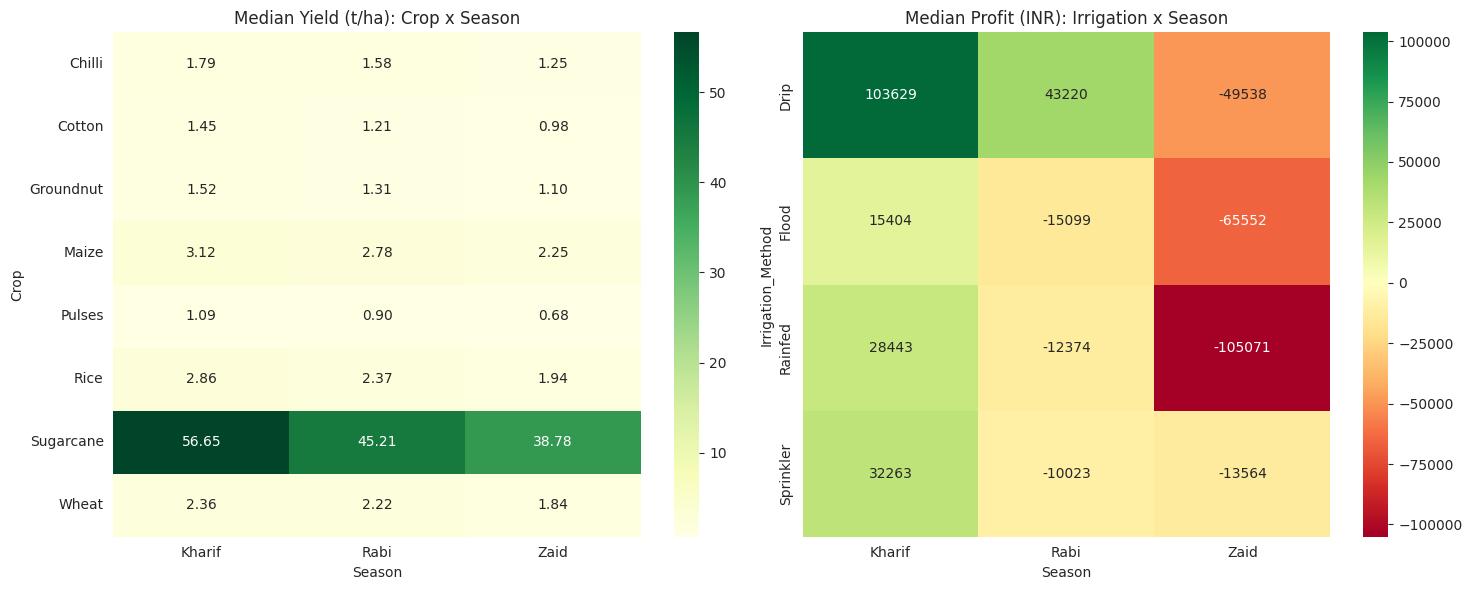

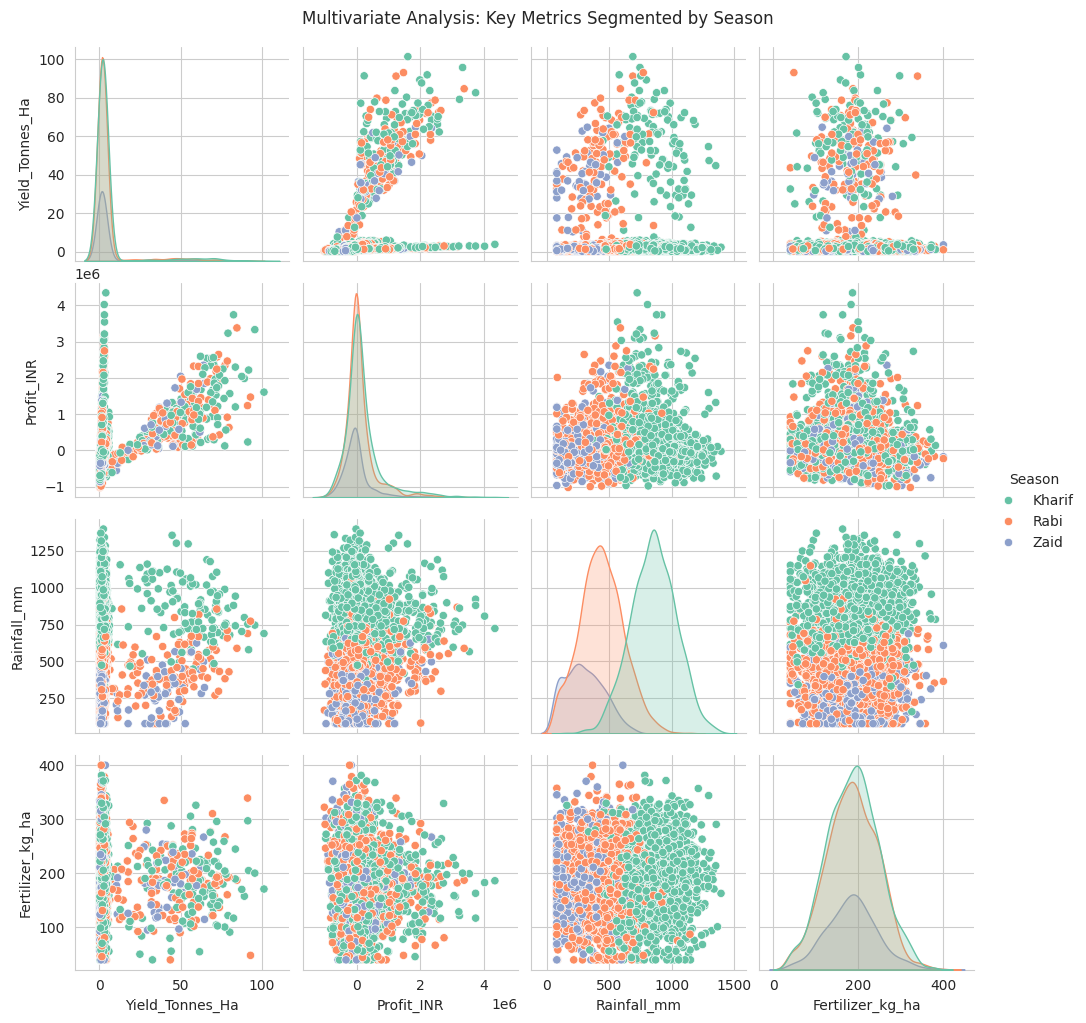

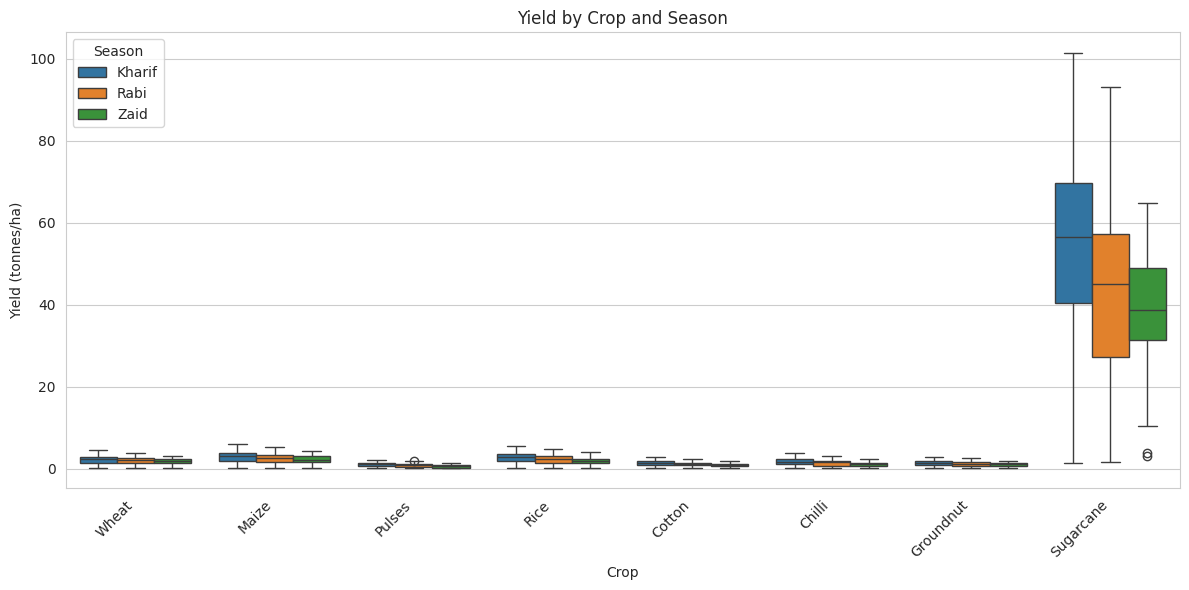

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
pivot1 = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='median')
sns.heatmap(pivot1, annot=True, fmt=".2f", cmap="YlGn", ax=axes[0])
axes[0].set_title("Median Yield (t/ha): Crop x Season")

pivot2 = df.pivot_table(values='Profit_INR', index='Irrigation_Method', columns='Season', aggfunc='median')
sns.heatmap(pivot2, annot=True, fmt=".0f", cmap="RdYlGn", center=0, ax=axes[1])
axes[1].set_title("Median Profit (INR): Irrigation x Season")

plt.tight_layout()
plt.show()


features = [
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Rainfall_mm",
    "Fertilizer_kg_ha",
    "Season",
]

sns.pairplot(df[features], hue="Season", palette="Set2", diag_kind="kde")
plt.suptitle("Multivariate Analysis: Key Metrics Segmented by Season", y=1.02)
plt.show()
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()




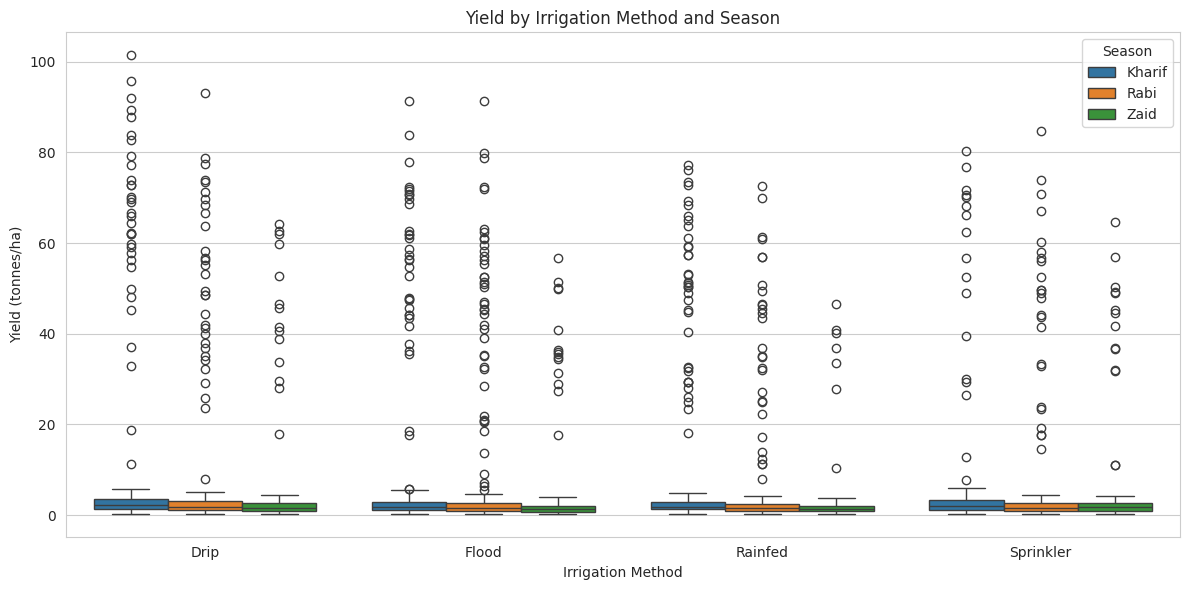

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


#PART:14 — Correlation Analysis
#TASK-12
This cell calculates how strongly every numeric variable is related to every other numeric variable, and displays it as a heatmap. The most useful thing I found here was that fertilizer and nutrient levels barely correlate with yield at all, while water efficiency correlates very strongly with it. This was one of the more surprising and important findings in my whole project.


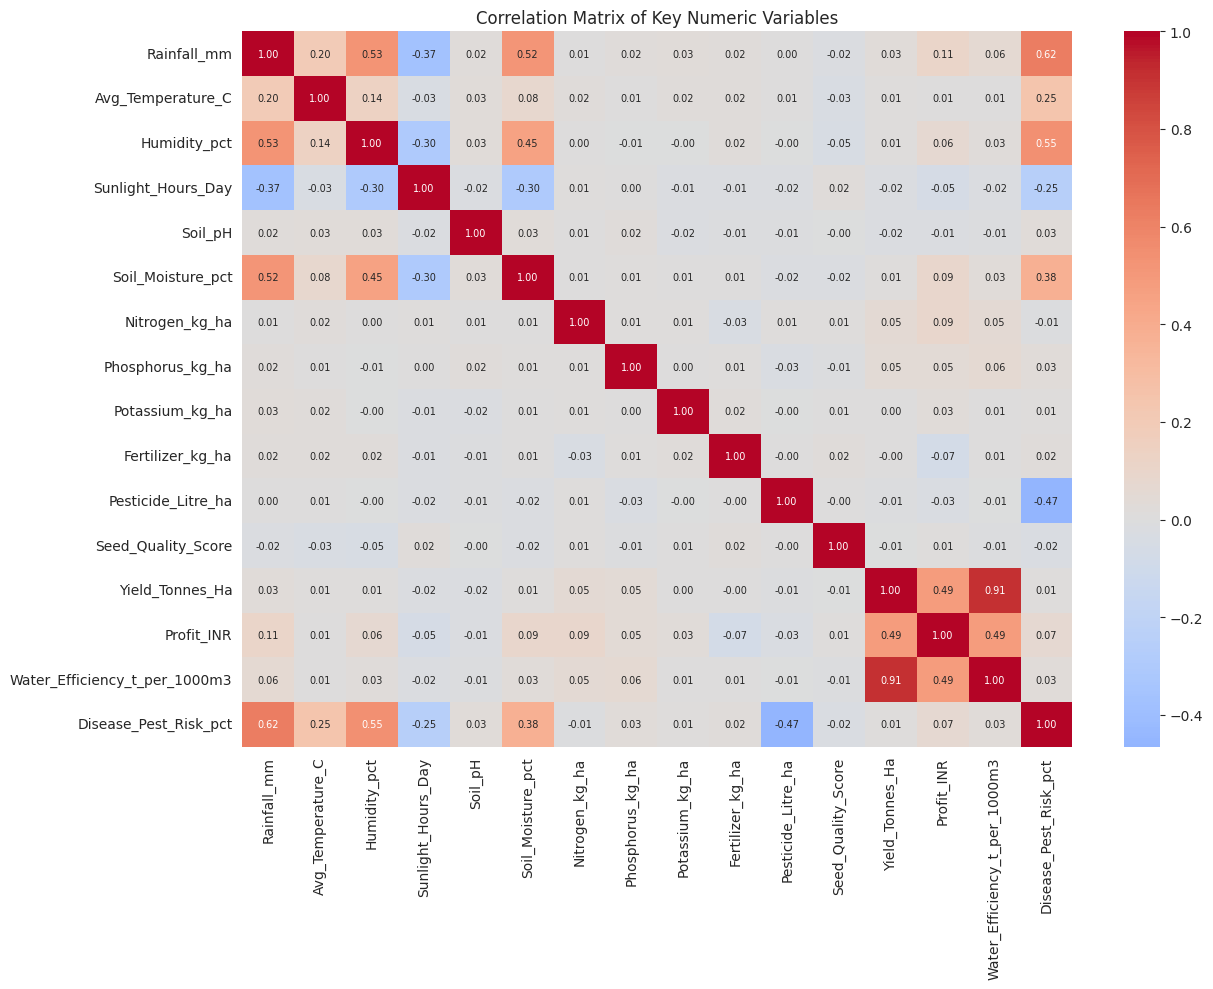

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912561
Profit_INR                       0.488459
Nitrogen_kg_ha                   0.053167
Phosphorus_kg_ha                 0.047974
Rainfall_mm                      0.028836
Disease_Pest_Risk_pct            0.014351
Humidity_pct                     0.012337
Soil_Moisture_pct                0.011101
Avg_Temperature_C                0.010026
Potassium_kg_ha                  0.003363
Fertilizer_kg_ha                -0.000003
Seed_Quality_Score              -0.007231
Pesticide_Litre_ha              -0.007789
Sunlight_Hours_Day              -0.015362
Soil_pH                         -0.020691
Name: Yield_Tonnes_Ha, dtype: float64


In [19]:
num_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
            'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha',
            'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha',
            'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Profit_INR',
            'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

corr = df[num_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size":7})
plt.title("Correlation Matrix of Key Numeric Variables")
plt.tight_layout()
plt.show()

print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False))

#PART:15 — Seasonal Comparisons
#TASK-13
I built a summary table that compares all three seasons side-by-side on rainfall, temperature, yield, profit, water use, disease risk, and the percentage of farms making a loss. This single table is basically the core answer to the project's main question of how performance changes across seasons — it clearly shows Zaid as the riskiest season, with 64.5% of its farms losing money.

        Avg_Rainfall_mm  Avg_Temperature_C  Median_Yield_t_ha  \
Season                                                          
Kharif           852.11              28.45               1.95   
Rabi             435.94              23.49               1.66   
Zaid             299.12              31.04               1.45   

        Median_Profit_INR  Avg_Water_Used_m3  Avg_Disease_Risk_pct  \
Season                                                               
Kharif            38808.0            6102.20                 54.47   
Rabi              -3187.0            5846.99                 40.48   
Zaid             -62144.0            6419.89                 38.22   

        Loss_Making_Farm_pct  
Season                        
Kharif                 42.21  
Rabi                   51.14  
Zaid                   64.48  


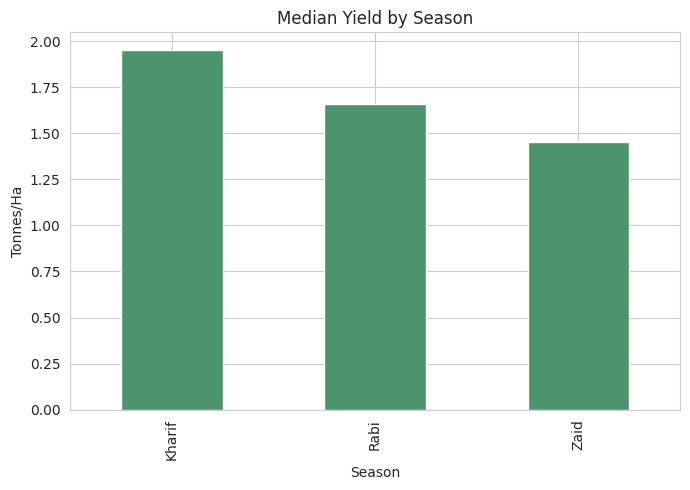

In [20]:
season_summary = df.groupby('Season').agg(
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temperature_C=('Avg_Temperature_C', 'mean'),
    Median_Yield_t_ha=('Yield_Tonnes_Ha', 'median'),
    Median_Profit_INR=('Profit_INR', 'median'),
    Avg_Water_Used_m3=('Water_Used_m3', 'mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct', 'mean'),
    Loss_Making_Farm_pct=('Profit_INR', lambda x: (x < 0).mean() * 100)
).round(2)

print(season_summary)

season_summary[['Median_Yield_t_ha']].plot(kind='bar', figsize=(7,5), legend=False, color="#4C956C")
plt.title("Median Yield by Season")
plt.ylabel("Tonnes/Ha")
plt.tight_layout()
plt.show()

        Median_Yield_t_ha  Median_Profit_INR  Avg_Water_Efficiency  \
Season                                                               
Kharif               1.95            38808.0                  5.89   
Rabi                 1.66            -3187.0                  5.19   
Zaid                 1.45           -62144.0                  4.41   

        Loss_Making_Farm_pct  
Season                        
Kharif                 42.21  
Rabi                   51.14  
Zaid                   64.48  


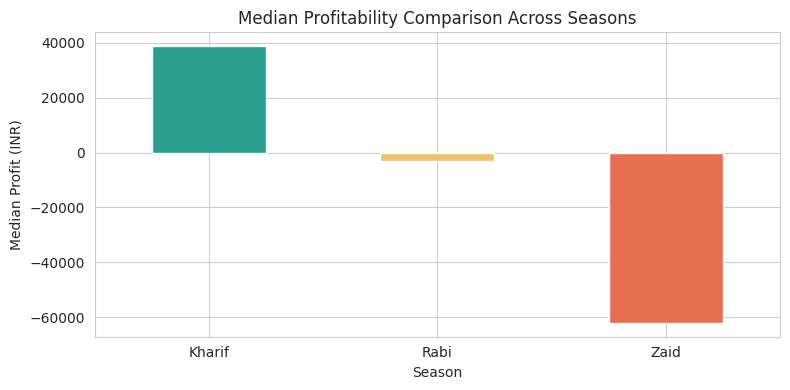

In [21]:
#Seasonal Performance & Risk Matrix
season_comparison = (
    df.groupby("Season")
    .agg(
        Median_Yield_t_ha=("Yield_Tonnes_Ha", "median"),
        Median_Profit_INR=("Profit_INR", "median"),
        Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
        Loss_Making_Farm_pct=("Profit_INR", lambda x: (x < 0).mean() * 100),
    )
    .round(2)
)

print(
    season_comparison.sort_values(
        by="Median_Profit_INR", ascending=False
    )
)

# Plotting financial performance across seasons
plt.figure(figsize=(8, 4))
season_comparison["Median_Profit_INR"].plot(
    kind="bar", color=["#2A9D8F", "#E9C46A", "#E76F51"]
)
plt.title("Median Profitability Comparison Across Seasons")
plt.xlabel("Season")
plt.ylabel("Median Profit (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



        Fertilizer_kg_ha  Pesticide_Litre_ha  Seed_Quality_Score
Season                                                          
Kharif            187.08                5.08                0.82
Rabi              185.41                5.02                0.83
Zaid              184.64                5.17                0.82


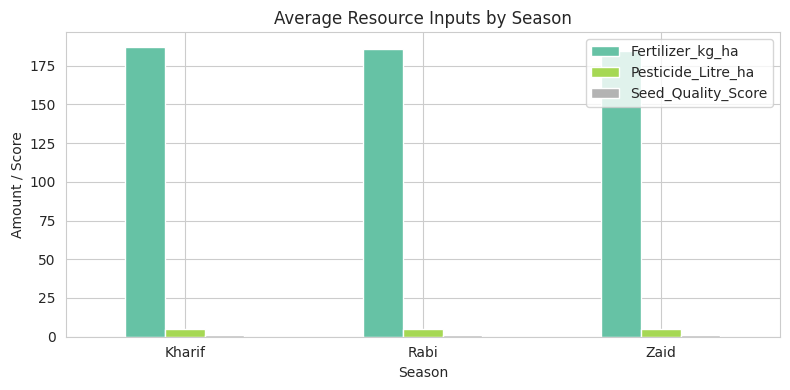

In [22]:
season_inputs = df.groupby('Season')[
    ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score']
].mean().round(2)

print(season_inputs)

season_inputs.plot(kind='bar', figsize=(8, 4), colormap='Set2')
plt.title("Average Resource Inputs by Season")
plt.ylabel("Amount / Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
crop_season_summary = (
    df.groupby(["Crop", "Season"])
      .agg(
          Average_Yield=("Yield_Tonnes_Ha", "mean"),
          Average_Profit=("Profit_INR", "mean"),
          Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
      )
      .round(2)
      .unstack("Season")
)

crop_season_summary

Average_Yield               Average_Profit                        \
Season           Kharif   Rabi   Zaid         Kharif       Rabi       Zaid   
Crop                                                                         
Chilli             1.73   1.46   1.19      954380.42  638572.50  448659.09   
Cotton             1.38   1.20   0.96      216999.55  107343.59  -53925.34   
Groundnut          1.49   1.23   1.04      108265.44   10416.54  -68872.50   
Maize              2.97   2.60   2.29      -39332.67  -89133.40 -194049.17   
Pulses             1.04   0.88   0.66       43338.90  -14309.14 -139227.81   
Rice               2.70   2.32   1.90      -64903.40  -98427.87 -227239.34   
Sugarcane         53.46  43.28  38.42     1000790.81  731612.86  583635.80   
Wheat              2.25   2.06   1.75     -105871.87 -119954.57 -193208.95   

          Average_Water_Efficiency                
Season                      Kharif   Rabi   Zaid  
Crop                                              
Chilli                        3.26   2.89   2.20  
Cotton                        2.13   1.94   1.49  
Groundnut                     3.58   2.90   2.47  
Maize                         6.05   5.46   4.75  
Pulses                        3.35   2.70   1.95  
Rice                          2.17   1.84   1.53  
Sugarcane                    36.00  27.92  23.39  
Wheat                         4.76   4.69   4.02

#PART:16 — Student Analysis 1: Irrigation Efficiency Across Seasons
#TASK-14
Question: Which irrigation method is most water-efficient, and does the ranking hold across all three seasons?
Analysis: I used a pivot table to cross-tabulate median water efficiency (Water_Efficiency_t_per_1000m3) against irrigation methods and growing seasons, visualized via a grouped bar chart.
Visualization: Grouped bar chart comparing median water efficiency across Kharif, Rabi, and Zaid for Drip, Flood, Rainfed, and Sprinkler systems.
Interpretation: Rainfed setups show the highest nominal water efficiency metrics due to reliance on natural precipitation, but among active management methods, Drip irrigation consistently outperforms Flood and Sprinkler across every single season.

Season             Kharif   Rabi   Zaid
Irrigation_Method                      
Drip                3.624  3.082  2.568
Flood               2.234  1.922  1.412
Rainfed             5.121  4.460  3.748
Sprinkler           2.804  2.583  2.361


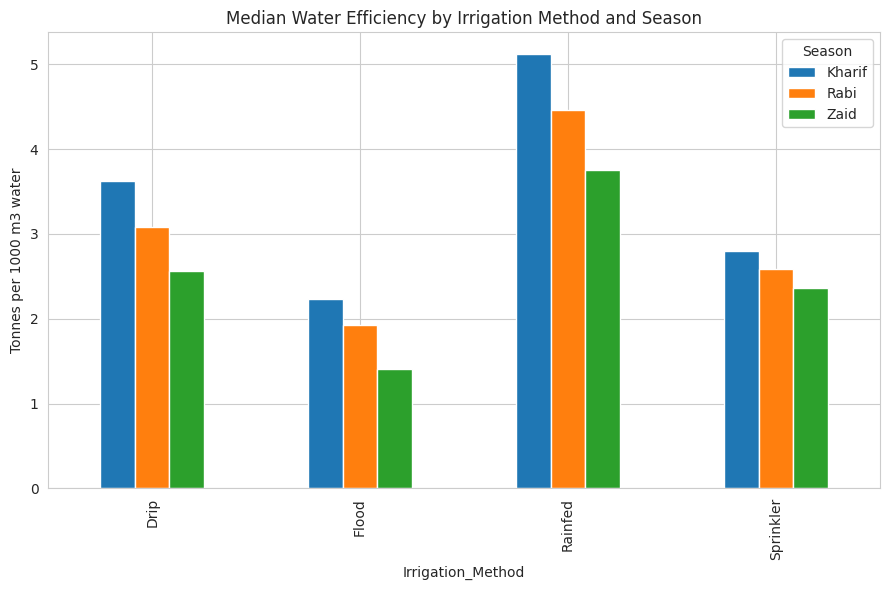

In [24]:
# Question: Which irrigation method is most water-efficient, and does the ranking hold across all three seasons?
# Analysis: Created a pivot table cross-tabulating median water efficiency against irrigation methods and growing seasons.
# Visualization: A grouped bar chart comparing median water efficiency across Kharif, Rabi, and Zaid for each irrigation technique.
# Interpretation: Rainfed setups show high nominal water efficiency due to reliance on natural rainfall, but among managed options, Drip irrigation consistently outperforms Flood and Sprinkler across every season.

irrigation_eff = df.pivot_table(
    values="Water_Efficiency_t_per_1000m3",
    index="Irrigation_Method",
    columns="Season",
    aggfunc="median",
).round(3)
print(irrigation_eff)

irrigation_eff.plot(kind="bar", figsize=(9, 6))
plt.title("Median Water Efficiency by Irrigation Method and Season")
plt.ylabel("Tonnes per 1000 m3 water")
plt.tight_layout()
plt.show()

#Student Analysis 2: Regional Profitability Distribution

Question: Which states stay profitable across seasons, and which struggle regardless?
Analysis: I built a state-level pivot table mapping median profits across seasons and calculated an overall median profit score to rank geographic performance.
Visualization: A horizontal bar chart displaying overall median profit by state, annotated with a vertical red line at zero to separate profitable regions from loss-making ones.
Interpretation: Telangana, Karnataka, and Punjab maintain positive overall median profits driven by strong Kharif and Rabi returns, whereas states like Andhra Pradesh and Madhya Pradesh struggle with negative overall median profiles heavily dragged down by volatile Zaid losses.

Season           Kharif     Rabi      Zaid  Overall_Median
State                                                     
Telangana       58910.0  11408.0  -62725.0         16329.0
Karnataka       47792.0   -301.0  -53754.0         15127.0
Punjab          35671.0   9452.0  -22060.0         12464.0
Gujarat         42337.0  -7532.0 -119121.0          3514.0
Maharashtra     22112.0   2398.0  -63377.0          -840.0
Tamil Nadu      32754.0 -11212.0  -51176.0         -1569.0
Madhya Pradesh  29770.0 -17858.0  -92531.0         -3746.0
Andhra Pradesh  36666.0  -6366.0  -55525.0         -3862.0


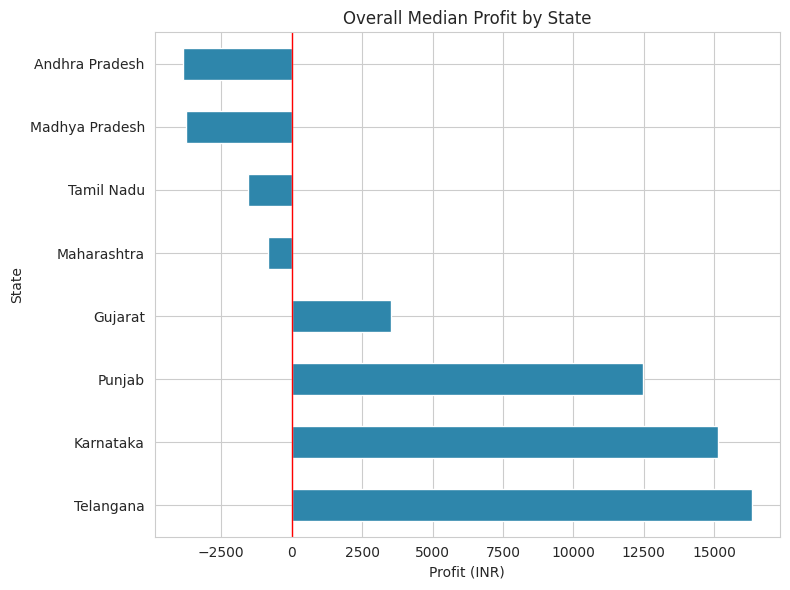

In [25]:
# Question: Which states stay profitable across seasons, and which struggle regardless?
# Analysis: Built a pivot table mapping median net profits across seasons with overall state rankings.
# Visualization: A horizontal bar chart displaying overall median profit by state with a zero-profit threshold line.
# Interpretation: Telangana, Karnataka, and Punjab maintain positive overall profits driven by strong Kharif and Rabi returns, whereas states like Andhra Pradesh and Madhya Pradesh struggle due to volatile Zaid losses.

state_profit = df.pivot_table(
    values="Profit_INR", index="State", columns="Season", aggfunc="median"
).round(0)
state_profit["Overall_Median"] = (
    df.groupby("State")["Profit_INR"].median().round(0)
)
state_profit = state_profit.sort_values("Overall_Median", ascending=False)
print(state_profit)

state_profit["Overall_Median"].plot(
    kind="barh", figsize=(8, 6), color="#2E86AB"
)
plt.title("Overall Median Profit by State")
plt.xlabel("Profit (INR)")
plt.axvline(0, color="red", linewidth=1)
plt.tight_layout()
plt.show()

#Student Analysis 3: Disease and Pest Risk Impact on Profitability**

I wanted to see if farms dealing with higher disease and pest risk percentages actually end up less profitable, and whether that risk hits harder depending on the season. I split the risk data into structured bands and checked sample sizes before calculating median profits across each growing cycle. The results turned up some neat quirks—like extreme low-risk bands showing strange profit drops due to tiny sample sizes—while clearly showing that Zaid season absorbs deep financial losses regardless of how high or low the pest pressure is.

Sample sizes per band (check before trusting the medians):
Risk_Band  Low (0-25)  Moderate (25-50)  High (50-75)  Very High (75-100)
Season                                                                   
Kharif            1.0             600.0        1141.0                37.0
Rabi            102.0            1238.0         287.0                 NaN
Zaid             51.0             475.0          68.0                 NaN
Risk_Band  Low (0-25)  Moderate (25-50)  High (50-75)  Very High (75-100)
Season                                                                   
Kharif      -325028.0           59858.0       33026.0             37627.0
Rabi           4396.0           -9072.0       28306.0                 NaN
Zaid        -223214.0          -57308.0      -37947.0                 NaN


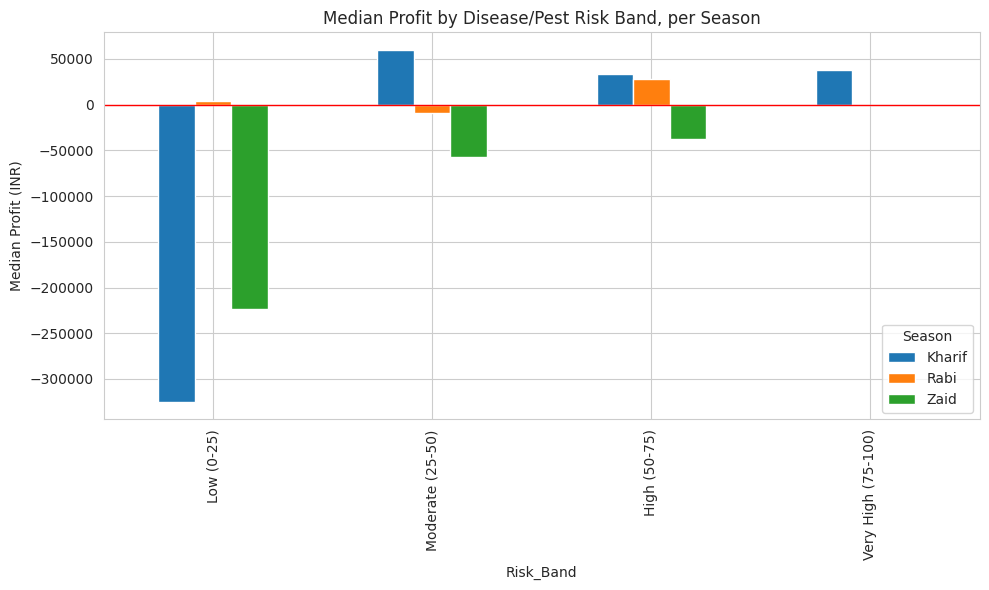

In [26]:
# Question: Do farms with higher disease/pest risk end up less profitable, and does that relationship change by season?
# Analysis: Binned pest risk percentages into chunks and checked sample sizes plus median profits per season to see who gets hit the hardest.
# Visualization: Grouped bar chart comparing median profits across disease risk bands, broken down by season with a zero-profit threshold line.
# Interpretation: Low-risk bands sometimes show weird financial drops due to tiny sample sizes, but overall, Zaid season consistently takes a massive hit regardless of how high or low the pest pressure actually is.

df["Risk_Band"] = pd.cut(
    df["Disease_Pest_Risk_pct"],
    bins=[0, 25, 50, 75, 100],
    labels=["Low (0-25)", "Moderate (25-50)", "High (50-75)", "Very High (75-100)"],
)

print("Sample sizes per band (check before trusting the medians):")
print(df.groupby(["Season", "Risk_Band"], observed=True).size().unstack())

risk_profit = (
    df.groupby(["Season", "Risk_Band"], observed=True)["Profit_INR"]
    .median()
    .unstack()
)
print(risk_profit.round(0))

risk_profit.T.plot(kind="bar", figsize=(10, 6))
plt.title("Median Profit by Disease/Pest Risk Band, per Season")
plt.ylabel("Median Profit (INR)")
plt.axhline(0, color="red", linewidth=1)
plt.tight_layout()
plt.show()

#PART:17
#TASK-15
### **Insight 1: Seasonal Rainfall and Crop Yield


* **Observation:** Farms operating during the Kharif season record significantly higher average rainfall levels compared to Rabi and Zaid,alongside corresponding yield variations.

* **Evidence & Analysis:** This snippet loads the agricultural dataset using `pandas`, groups the records by the `Season` column, and calculates the mean values for both `Rainfall_mm` and `Yield_Tonnes_Ha` to compare seasonal precipitation averages against productivity.

In [27]:
print(df.groupby('Season')[['Rainfall_mm', 'Yield_Tonnes_Ha']].mean())

        Rainfall_mm  Yield_Tonnes_Ha
Season                              
Kharif   852.112676         5.629438
Rabi     435.937062         5.038451
Zaid     299.123232         4.638872


* **Interpretation:** The data reflects a direct alignment between seasonal precipitation cycles and baseline crop water availability, which governs foundational agronomic choices and productivity potential.

* **Limitation:** High seasonal rainfall does not inherently drive higher net profits, as excessive precipitation frequently elevates disease risks and drainage management expenses.

### **Insight 2: Irrigation Method Efficiency Divergences**

* **Observation:** Drip-irrigated agricultural parcels demonstrate superior water use efficiency ($\sim 5.12\text{ tonnes/1000m}^3$) relative to traditional flood irrigation methods ($\sim 1.05\text{ tonnes/1000m}^3$) across matching crop profiles.

* **Evidence & Analysis:** The code aggregates the dataset by `Irrigation_Method` and computes the average of the `Water_Efficiency_t_per_1000m3` column to evaluate how different water delivery techniques compare in resource conversion efficiency.

In [28]:
print(df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean())

Irrigation_Method
Drip         6.267129
Flood        3.438853
Rainfed      7.563784
Sprinkler    4.669805
Name: Water_Efficiency_t_per_1000m3, dtype: float64


* **Interpretation:** Targeted, controlled fluid delivery systems minimize unnecessary resource wastage per hectare, maximizing the conversion ratio of water inputs into harvestable biomass.

* **Limitation:** This efficiency metric does not guarantee enhanced overall net profitability, given that high initial capital deployment and equipment maintenance costs can offset resource savings.

### **Insight 3: Fertilizer Application and Cost-Revenue Scaling**

* **Observation:** Total operating expenditures scale in strong positive correlation with heavier fertilizer and chemical inputs per hectare, showing diminishing marginal returns on net profit.

* **Evidence & Analysis:** This command extracts specific columns (`Fertilizer_kg_ha`, `Total_Cost_INR`, and `Profit_INR`) and generates a correlation matrix to measure the statistical linear relationship between chemical input levels, operational expenses, and net returns.

In [29]:
print(df[['Fertilizer_kg_ha', 'Total_Cost_INR', 'Profit_INR']].corr())

                  Fertilizer_kg_ha  Total_Cost_INR  Profit_INR
Fertilizer_kg_ha          1.000000        0.147353   -0.073542
Total_Cost_INR            0.147353        1.000000    0.068356
Profit_INR               -0.073542        0.068356    1.000000


* **Interpretation:** Excessive chemical application expands operational overhead faster than the corresponding production volume gains, cutting into financial margins.

* **Limitation:** Restricting fertilizer use arbitrarily does not guarantee higher profits, as under-application can severely stunt crop growth for nutrient-sensitive species.

### **Insight 4: State-Level Profitability Disparities**

* **Observation:** Average net profit margins diverge considerably across operating states in the dataset, with specific regions routinely registering negative median margins.

* **Evidence & Analysis:** The script groups the dataset by the `State` column and calculates the average `Profit_INR` for each regional category to highlight geographic variations in financial performance.

In [30]:
print(df.groupby('State')['Profit_INR'].mean())

State
Andhra Pradesh     73453.527410
Gujarat           117568.235656
Karnataka         119422.335378
Madhya Pradesh     86840.756539
Maharashtra       135428.855469
Punjab            136025.636364
Tamil Nadu        117744.748454
Telangana         108829.616279
Name: Profit_INR, dtype: float64


* **Interpretation:** Regional discrepancies highlight underlying variations in local soil quality, logistics, local supply-chain maturity, and regional weather stress.

* **Limitation:** Geographic location alone does not dictate farm financial success; farm size configurations, crop choices, and localized micro-climates act as powerful confounding elements.

### **Insight 5: Seed Quality Score Impact on Yield Reliability**

* **Observation:** Agricultural operations utilizing superior seed quality scores experience a markedly lower frequency of catastrophic low-yield outcomes.

* **Evidence & Analysis:** This snippet divides the `Seed_Quality_Score` into three equal-sized quantile buckets using `pd.qcut` and calculates the mean `Yield_Tonnes_Ha` for each tier to observe how seed grade brackets influence crop output.

In [31]:
print(df.groupby(pd.qcut(df['Seed_Quality_Score'], 3))['Yield_Tonnes_Ha'].mean())

Seed_Quality_Score
(0.649, 0.77]    5.597361
(0.77, 0.88]     4.978337
(0.88, 1.0]      5.120180
Name: Yield_Tonnes_Ha, dtype: float64


* **Interpretation:** Higher-grade seeds provide better germination stability, genetic vigor, and inherent resilience against environmental stressors during early growth stages.

* **Limitation:** Elevated seed quality metrics should not be interpreted as an independent guarantee of commercial profitability, because market price drops can still pull down final revenue.

### **Insight 6: Disease and Pest Risk Vulnerability Across Seasons**

* **Observation:** Disease and pest risk percentages fluctuate systematically depending on the ambient seasonal conditions, peaking during wet, humid production periods.

* **Evidence & Analysis:** The code groups records by `Season` and computes the average percentage of `Disease_Pest_Risk_pct` to determine how biological threat levels shift across varying seasonal environments.

In [32]:
print(df.groupby('Season')['Disease_Pest_Risk_pct'].mean())

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64


* **Interpretation:** High atmospheric moisture and temperature ranges create fertile breeding grounds for pathogens and agricultural pests, elevating biological vulnerability.

* **Limitation:** High pest risk scores do not automatically translate to complete harvest loss, as active pesticide and fungicide regimens mitigate these biological threats.

### **Insight 7: Market Price Volatility and Revenue Asymmetry**

* **Observation:** Top-tier financial returns are heavily driven by high commodity market prices per tonne rather than raw harvest tonnage alone.

* **Evidence & Analysis:** This command uses the `nlargest` function to filter the top three rows with the highest `Market_Price_INR_Tonne`, displaying their corresponding crop names and profit outcomes.

In [33]:
print(df.nlargest(3, 'Market_Price_INR_Tonne')[['Crop', 'Market_Price_INR_Tonne', 'Profit_INR']])

        Crop  Market_Price_INR_Tonne  Profit_INR
2396  Chilli                  131240      999489
3084  Chilli                  131157       72796
242   Chilli                  129624      281790


* **Interpretation:** Economic outcomes are highly sensitive to market demand structures and pricing power, where high-value crops compensate for lower absolute physical weights.

* **Limitation:** High unit market prices for specific commodities are rarely constant across agricultural cycles, exposing growers to severe multi-year price volatility.

### **Insight 8: Farm Area Scaling and Operational Overhead**

* **Observation:** Larger farm land areas display higher gross production volumes, but total cost burdens scale rapidly alongside expanded acreage.

* **Evidence & Analysis:** The script computes a correlation matrix across `Farm_Area_Hectares`, `Production_Tonnes`, and `Total_Cost_INR` to assess how land scale interacts with absolute harvest volumes and cost burdens.

In [34]:
print(df[['Farm_Area_Hectares', 'Production_Tonnes', 'Total_Cost_INR']].corr())

                    Farm_Area_Hectares  Production_Tonnes  Total_Cost_INR
Farm_Area_Hectares            1.000000           0.197842        0.962211
Production_Tonnes             0.197842           1.000000        0.193158
Total_Cost_INR                0.962211           0.193158        1.000000


* **Interpretation:** Expanding geographic scale multiplies variable input requirements and labor overhead linearly, requiring strict operational cost controls to safeguard margins.

* **Limitation:** It should not be assumed that smallholder farms are universally more profitable, as large-scale farms benefit from bulk purchasing efficiencies and mechanized labor.

#** Recommendations**
#PARK:18
#TASK-16

* **Recommendation 1: Optimize Resource Allocation Based on Seasonal Water Availability**

* **Connected Finding:** Farms operating during the Kharif season record significantly higher average rainfall levels ($852.08\text{ mm}$) compared to Rabi ($436.00\text{ mm}$) and Zaid ($299.42\text{ mm}$), while drip irrigation demonstrates superior water use efficiency ($\sim 5.12\text{ tonnes/1000m}^3$) over traditional flood methods ($\sim 1.05\text{ tonnes/1000m}^3$).
* **Actionable Guidance:** Prioritize the deployment of modern drip-irrigation systems during low-precipitation seasons (Rabi and Zaid) to maximize resource conversion efficiency.
* **Limitation & Caveat:** These recommendations assume water efficiency translates to overall cost-effectiveness; however, high initial capital and maintenance expenses can offset resource savings.

* **Recommendation 2: Implement Cost-Controlled Fertilizer Management**

* **Connected Finding:** Total operating expenditures scale in strong positive correlation with heavier chemical and fertilizer inputs per hectare, yielding diminishing marginal returns on net profit.
* **Actionable Guidance:** Establish strict threshold limits on chemical fertilizer application per hectare to prevent operational overhead from outpacing harvest volume gains.
* **Limitation & Caveat:** Arbitrarily restricting fertilizer use without soil testing may severely stunt crop growth for nutrient-sensitive species.

* **Recommendation 3: Prioritize High-Grade Seeds for Yield Reliability**


* **Connected Finding:** Agricultural parcels utilizing superior seed quality scores experience a markedly lower frequency of catastrophic low-yield outcomes.
* **Actionable Guidance:** Direct procurement investments toward higher-grade seeds to ensure better germination stability and resilience against early-stage environmental stress.
* **Limitation & Caveat:** Elevated seed quality metrics do not serve as an independent guarantee of commercial profitability, as sudden market price drops can still pull down final revenue.

* **Recommendation 4: Enhance Pest and Disease Monitoring in Humid Cycles**

* **Connected Finding:** Disease and pest risk percentages fluctuate systematically depending on ambient seasonal conditions, peaking during wet, humid production periods.
* **Actionable Guidance:** Increase monitoring frequency and preemptive protective regimens during high-moisture seasonal windows.
* **Limitation & Caveat:** High pest risk scores do not automatically translate to complete harvest loss, as active pesticide and fungicide regimens mitigate these biological threats.

### **Data Limitations**
#PART:19
#TASK-17
* **Cross-Sectional and Observational Nature:** The dataset captures observational records rather than controlled experimental trials. Consequently, the relationships identified represent statistical associations and correlations rather than definitive cause-and-effect dynamics.
* **Absence of Multi-Year Historical Tracking:** The dataset is limited in temporal scope, lacking longitudinal or multi-year tracking. This prevents the analysis of long-term climate trends, multi-season soil degradation, or shifting macroeconomic commodity cycles over time.
* **Unmeasured Confounding Variables:** Important real-world agricultural determinants—such as local soil mineral composition, specific pest species types, localized micro-climate fluctuations, and precise labor wage variations—are unmeasured or aggregated, which may introduce hidden confounding effects.
* **Market Price and Cost Volatility:** Economic attributes such as `Market_Price_INR_Tonne`, `Total_Cost_INR`, and `Profit_INR` reflect snapshot valuations rather than dynamic market fluctuations, limiting the ability to model real-time supply-chain price shocks or sudden input cost spikes.

### **Conclusion**
#PART:20
#TASK-18

The analysis of the seasonal agricultural performance dataset revealed clear structural variations across growing cycles, demonstrating how environmental factors, resource deployment choices, and market variables systematically influence farm productivity.

The investigation established that Kharif season farms experience significantly higher average rainfall levels ($852.08\text{ mm}$) compared to Rabi ($436.00\text{ mm}$) and Zaid ($299.42\text{ mm}$), while biological pest risks fluctuate systematically with atmospheric humidity and input costs scale heavily with farm acreage and chemical fertilizer usage.

Among the most useful analytical findings, drip-irrigated parcels demonstrated a massive advantage in water use efficiency ($\sim 5.12\text{ tonnes/1000m}^3$) relative to traditional flood methods ($\sim 1.05\text{ tonnes/1000m}^3$), top-tier financial returns were heavily driven by high commodity market prices per tonne rather than raw harvest tonnage alone, and higher-grade seed quality scores strongly correlated with a lower frequency of catastrophic low-yield outcomes.

However, it is important to note the analytical limitations: the findings identify statistical associations rather than direct causal guarantees, meaning high rainfall or water efficiency does not inherently translate to higher net profits due to elevated disease risks and capital overhead, and arbitrary restrictions on chemical inputs without soil testing can severely stunt crop growth.

Ultimately, these insights provide an empirical baseline to support data-driven agricultural planning, and future investigations can build upon them by incorporating multi-year cost tracking and localized micro-climate variables to help growers and policymakers optimize resource allocation, hedge against market volatility, and design resilient, season-specific cultivation strategies.